iteration 22 results |k={K}
Log Likelihood: -126085.68
silhoutte: 0.178
cluster profile(means,original scale) - Iteration 22 GaussianMixture(RobustScaler) diag, labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
12855,57.24304955622894,2.0,21.455532573791952,28.62152477811447,0.31,0.2946272260579995,0.5597539673993284
57114,19.34305332401712,1.0,20.666521802684432,19.34305332401712,0.355,0.27212593332489615,0.5139219652872268
7548,112.49850438850531,3.703,22.154456682187185,30.192980855504555,0.296,0.3043722938718867,0.5802276314857678
30483,60.80104438948252,1.0,21.755333679562387,60.80104438948252,0.285,0.30450124317288985,0.5840512934217855


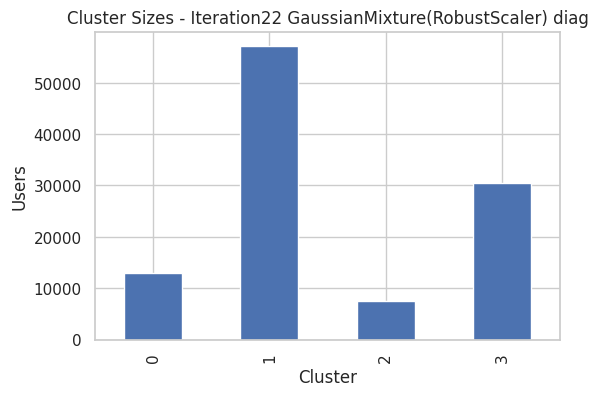

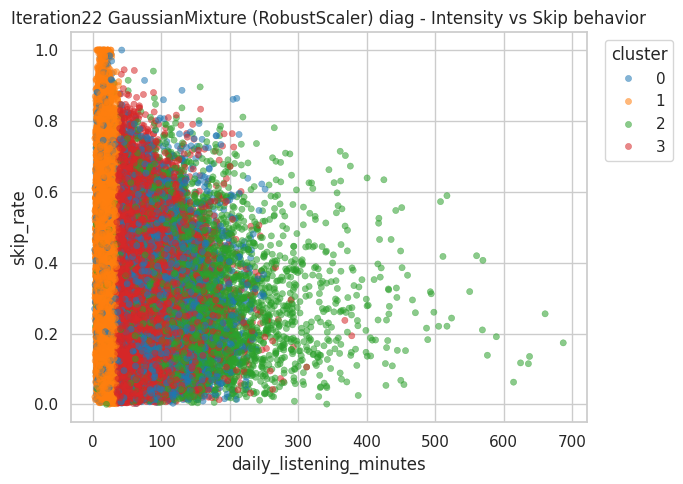

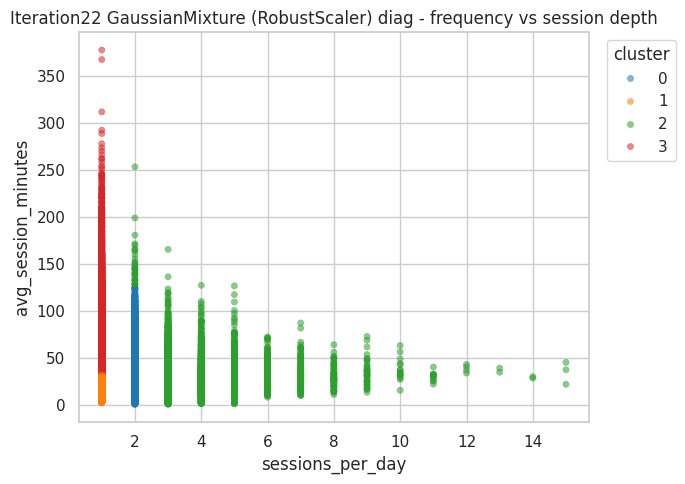

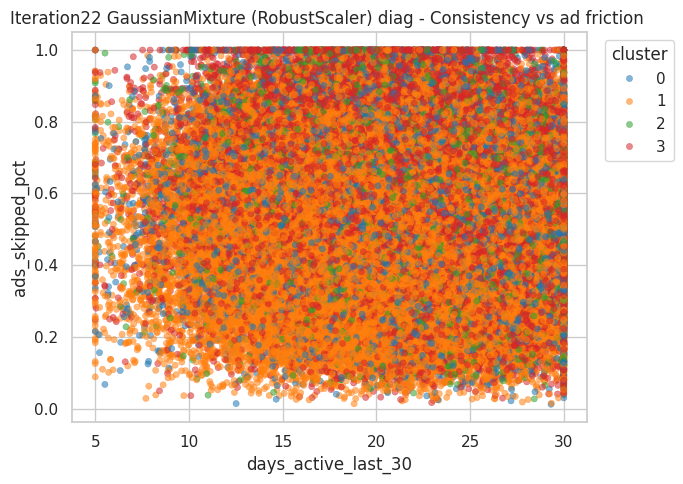

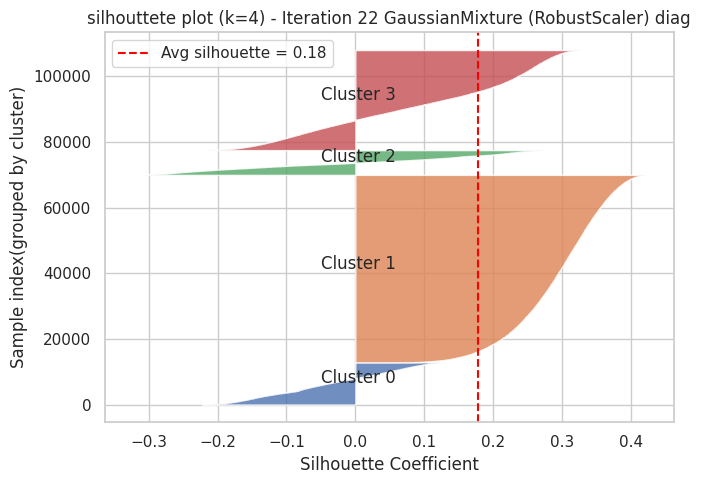

In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score , silhouette_samples

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

K = 4

X22 = base[CLUSTER_FEATURES_V1].copy()
Robust = RobustScaler()
X22_Robust = Robust.fit_transform(X22)

X22 = pd.DataFrame(
    X22_Robust,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

gmm22 = GaussianMixture(
    n_components=K,
    random_state=42,
    covariance_type="diag",
    n_init=5,
    max_iter=200
)

labels22 = gmm22.fit_predict(X22)

log_likelihood22 = gmm22.score(X22) * len(X22)
sil_avg_22 = silhouette_score(X22, labels22)

base_iter22 = base.copy()
base_iter22["cluster"] = labels22

print("iteration 22 results |k={K}")
print("Log Likelihood:", round(log_likelihood22, 2))
print("silhoutte:", round(sil_avg_22, 3))

sizes22 = base_iter22["cluster"].value_counts().sort_index()
means22 = (
    base_iter22
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile22 = means22.copy()
profile22.insert(0, "cluster_size", sizes22)

print("cluster profile(means,original scale) - Iteration 22 GaussianMixture(RobustScaler) diag, labels):")
display(profile22)

plt.figure(figsize=(6,4))
base_iter22["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration22 GaussianMixture(RobustScaler) diag")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter22,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration22 GaussianMixture (RobustScaler) diag - Intensity vs Skip behavior")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter22,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration22 GaussianMixture (RobustScaler) diag - frequency vs session depth")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter22,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration22 GaussianMixture (RobustScaler) diag - Consistency vs ad friction ")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

sil_values_22 = silhouette_samples(X22, labels22)

plt.figure(figsize=(7,5))
y_lower = 0

vals0 = sil_values_22[labels22 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

vals1 = sil_values_22[labels22 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

vals2 = sil_values_22[labels22 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

vals3 = sil_values_22[labels22 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sil_avg_22,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg_22:.2f}"
)

plt.title("silhouttete plot (k=4) - Iteration 22 GaussianMixture (RobustScaler) diag")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()
